In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import re
import string

## **Loading Dataset and Dataset Analysis**

In [25]:
def load_dataset():
    train_df = pd.read_csv(r"C:\Users\maria\Desktop\junior year\term 5\deep learning\labs\jigsaw-multilingual-toxic-comment-dl\data\jigsaw-multilingual-toxic-comment-classification.csv")
    validation_df = pd.read_csv(r"C:\Users\maria\Desktop\junior year\term 5\deep learning\labs\jigsaw-multilingual-toxic-comment-dl\data\validation.csv")
    test_df = pd.read_csv(r"C:\Users\maria\Desktop\junior year\term 5\deep learning\labs\jigsaw-multilingual-toxic-comment-dl\data\test.csv")
    
    return train_df, validation_df, test_df

In [26]:
def dataset_analysis(df, df_name):
    print(f"=== {df_name} Dataset Analysis ===")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nMissing Values:")
    print(df.isnull().sum())
    print(f"\nData Types:\n{df.dtypes}")
    
    if 'toxic' in df.columns:
        print(f"\nClass Distribution:")
        print(df['toxic'].value_counts())
        print(f"Toxic Ratio: {df['toxic'].mean():.3f}")
    
    return df

In [27]:
train_df, val_df, test_df = load_dataset()
train_df = dataset_analysis(train_df, "Training")

=== Training Dataset Analysis ===
Shape: (223549, 11)
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'input_word_ids', 'input_mask', 'all_segment_id']

Missing Values:
id                0
comment_text      0
toxic             0
severe_toxic      0
obscene           0
threat            0
insult            0
identity_hate     0
input_word_ids    0
input_mask        0
all_segment_id    0
dtype: int64

Data Types:
id                object
comment_text      object
toxic              int64
severe_toxic       int64
obscene            int64
threat             int64
insult             int64
identity_hate      int64
input_word_ids    object
input_mask        object
all_segment_id    object
dtype: object

Class Distribution:
toxic
0    202165
1     21384
Name: count, dtype: int64
Toxic Ratio: 0.096


### *Handle Class Imbalance*

In [28]:
from sklearn.utils import class_weight
import warnings
warnings.filterwarnings('ignore')

def handle_imbalance(y_train):
    """Calculate class weights to handle imbalance"""
    class_weights = class_weight.compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    print(f"Class distribution: {np.bincount(y_train)}")
    print(f"Class weights: {class_weight_dict}")
    
    return class_weight_dict

# Store the original labels before preprocessing
original_train_labels = train_df['toxic'].values
original_val_labels = val_df['toxic'].values

# Calculate class weights using original data
class_weights = handle_imbalance(original_train_labels)

Class distribution: [202165  21384]
Class weights: {0: np.float64(0.5528874928894715), 1: np.float64(5.227015525626637)}


## **Data Visualization**

### *Class Distribution (Univariate)*

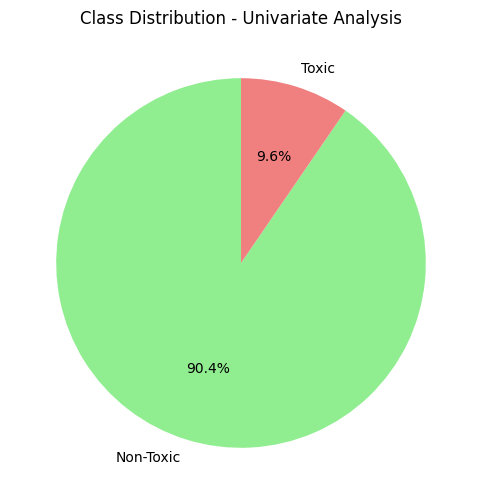

Non-Toxic: 202,165 samples
Toxic: 21,384 samples


In [29]:
plt.figure(figsize=(8, 6))
toxic_counts = train_df['toxic'].value_counts()
plt.pie(toxic_counts.values, labels=['Non-Toxic', 'Toxic'], autopct='%1.1f%%', 
        colors=['lightgreen', 'lightcoral'], startangle=90)
plt.title('Class Distribution - Univariate Analysis')
plt.show()

print(f"Non-Toxic: {toxic_counts[0]:,} samples")
print(f"Toxic: {toxic_counts[1]:,} samples")

### *Text Length Distribution (Univariate)*

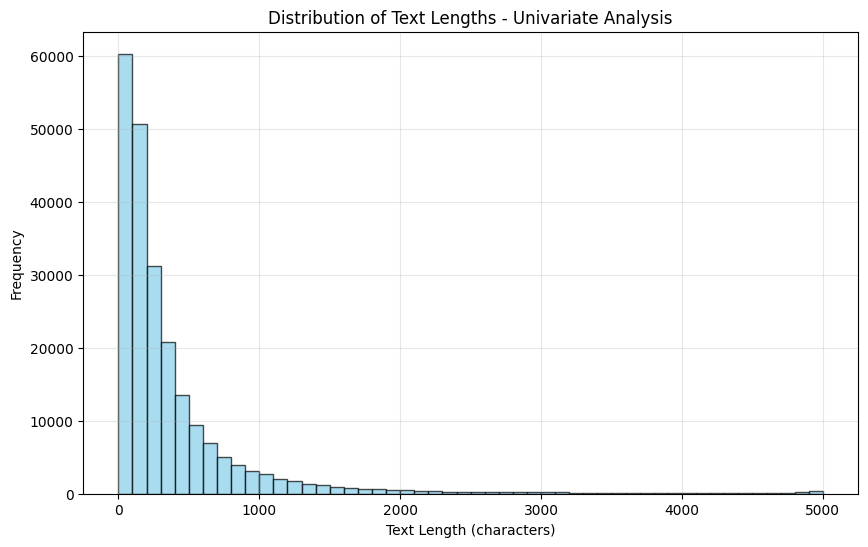

Mean text length: 391.0 characters
Median text length: 203.0 characters


In [30]:
plt.figure(figsize=(10, 6))
train_df['text_length'] = train_df['comment_text'].apply(len)
plt.hist(train_df['text_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Text Lengths - Univariate Analysis')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()
print(f"Mean text length: {train_df['text_length'].mean():.1f} characters")
print(f"Median text length: {train_df['text_length'].median():.1f} characters")

### *Text Length vs Toxicity (Bivariate)*

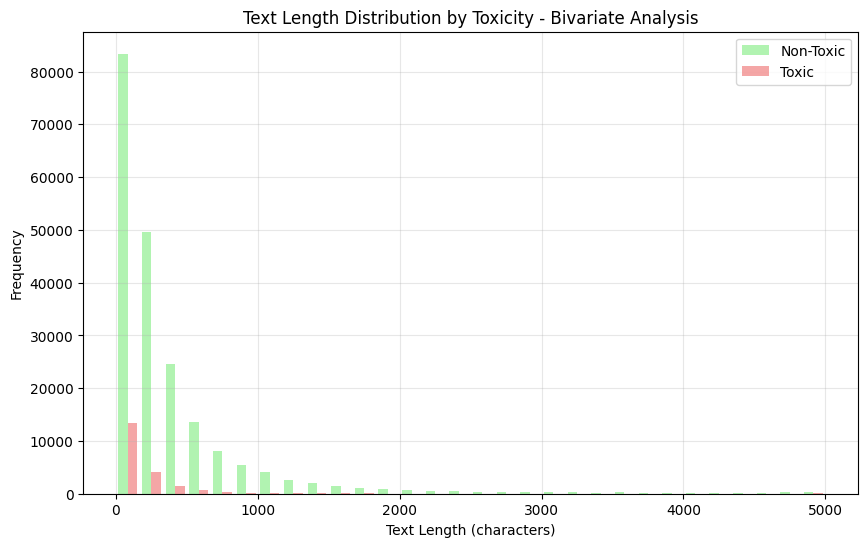

Non-Toxic mean length: 402.7
Toxic mean length: 280.6


In [31]:
plt.figure(figsize=(10, 6))

toxic_text_len = train_df[train_df['toxic'] == 1]['text_length']
non_toxic_text_len = train_df[train_df['toxic'] == 0]['text_length']

plt.hist([non_toxic_text_len, toxic_text_len], 
         bins=30, label=['Non-Toxic', 'Toxic'], alpha=0.7,
         color=['lightgreen', 'lightcoral'])
plt.title('Text Length Distribution by Toxicity - Bivariate Analysis')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Non-Toxic mean length: {non_toxic_text_len.mean():.1f}")
print(f"Toxic mean length: {toxic_text_len.mean():.1f}")

### *Feature Correlation (Multivariate)*

In [32]:
train_df['word_count'] = train_df['comment_text'].apply(lambda x: len(str(x).split()))
train_df['char_count'] = train_df['comment_text'].apply(lambda x: len(str(x).replace(" ", "")))
train_df['avg_word_length'] = train_df['char_count'] / train_df['word_count']

In [33]:
numerical_cols = ['toxic', 'text_length', 'word_count', 'char_count', 'avg_word_length']
correlation_data = train_df[numerical_cols].corr()

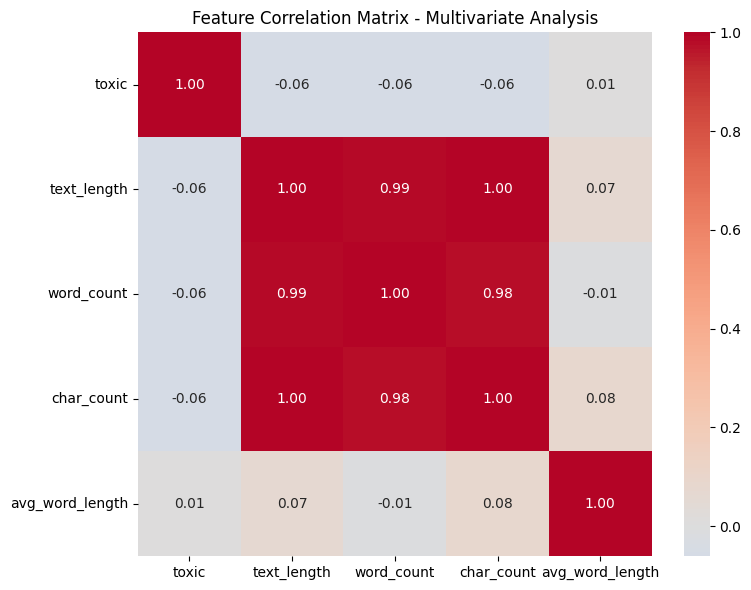

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix - Multivariate Analysis')
plt.tight_layout()
plt.show()

In [35]:
print("Correlation with Toxicity:")
for feature in ['text_length', 'word_count', 'char_count', 'avg_word_length']:
    corr = correlation_data.loc['toxic', feature]
    print(f"  {feature}: {corr:.3f}")

Correlation with Toxicity:
  text_length: -0.061
  word_count: -0.059
  char_count: -0.061
  avg_word_length: 0.007


## **Data Cleaning and Preprocessing**

In [36]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### *Download NLTK resources*

In [37]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

### *Comprehensive text cleaning function*

In [38]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)  
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

### *Create additional text features for normalization*

In [39]:
def create_text_features(texts):
    features = []
    for text in texts:
        if not isinstance(text, str):
            features.append([0, 0, 0, 0])
            continue
            
        text_len = len(text)
        word_count = len(text.split())
        char_count = len(text.replace(" ", ""))
        avg_word_len = char_count / max(word_count, 1)

        special_chars = len(re.findall(r'[!@#$%^&*()_+\-=\[\]{};\':"\\|,.<>/?]', text))
        
        features.append([text_len, word_count, char_count, avg_word_len, special_chars])
    
    return np.array(features)

### *Apply Standard Scaling to text features*

In [40]:
def normalize_features(features, scaler=None, fit=True):
    from sklearn.preprocessing import StandardScaler
    
    if scaler is None:
        scaler = StandardScaler()

    if fit:
        normalized_features = scaler.fit_transform(features)
    else:
        normalized_features = scaler.transform(features)

    return normalized_features, scaler

### *Data augmentation for text data*

#### *<center>Techniques: synonym replacement, random insertion, random swap, random deletion</center>*

In [41]:
def augment_text_data(texts, labels, augmentation_factor=0.1):
    augmented_texts = list(texts)
    augmented_labels = list(labels)

    def simple_augment(text):
        words = text.split()
        if len(words) <= 1:
            return text
  
        if len(words) >= 2:
            idx1, idx2 = np.random.choice(len(words), 2, replace=False)
            words[idx1], words[idx2] = words[idx2], words[idx1]
        
        words = [word for word in words if np.random.random() > 0.1]
        return ' '.join(words)
    
    n_augment = int(len(texts) * augmentation_factor)
    indices_to_augment = np.random.choice(len(texts), n_augment, replace=False)
    
    for idx in indices_to_augment:
        augmented_text = simple_augment(texts[idx])
        augmented_texts.append(augmented_text)
        augmented_labels.append(labels[idx])
    
    return np.array(augmented_texts), np.array(augmented_labels)

### *Preprocessing Function*

In [42]:
def preprocess_data(df, text_column='comment_text', label_column='toxic', augmentation=False, feature_normalization=True):

    df['cleaned_text'] = df[text_column].apply(clean_text)
    df = df.dropna(subset=[text_column])
    texts = df['cleaned_text'].values
    labels = df[label_column].values if label_column in df.columns else None

    if augmentation and labels is not None:
        print("Applying data augmentation...")
        texts, labels = augment_text_data(texts, labels)
        print(f"After augmentation: {len(texts)} samples")

    if feature_normalization:
        print("Creating and normalizing text features...")
        text_features = create_text_features(texts)
        normalized_features, scaler = normalize_features(text_features, fit=True)
        
        feature_info = {
            'features': normalized_features,
            'scaler': scaler,
            'feature_names': ['text_length', 'word_count', 'char_count', 'avg_word_len', 'special_chars']
        }
    else:
        feature_info = None
    
    return texts, labels, feature_info

In [43]:
train_texts, train_labels, train_feature_info = preprocess_data(train_df, augmentation=True, feature_normalization=True)
val_texts, val_labels, val_feature_info = preprocess_data(val_df, augmentation=False, feature_normalization=True)

print(f"Sample cleaned text: {train_texts[0][:200]}...")
print(f"Corresponding label: {train_labels[0]}")
print(f"Normalized features sample: {train_feature_info['features'][0] if train_feature_info else 'None'}")

Applying data augmentation...
After augmentation: 245903 samples
Creating and normalizing text features...
Creating and normalizing text features...
Sample cleaned text: explanation why the edits made under my username hardcore metallica fan were reverted they weren t vandalisms just closure on some gas after i voted at new york dolls fac and please don t remove the t...
Corresponding label: 0
Normalized features sample: [-0.18622372 -0.16857061 -0.18955821 -0.04277838 -0.02320178]


### *Analyze Vocabulary by Class*

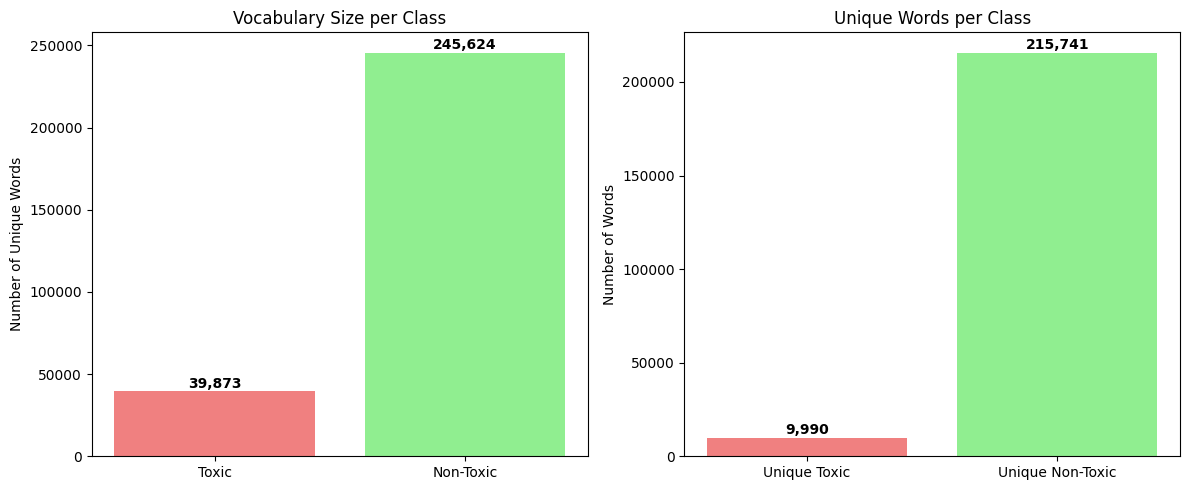

Total unique words - Toxic: 39,873, Non-Toxic: 245,624
Unique to Toxic: 9,990, Unique to Non-Toxic: 215,741


In [44]:
def analyze_vocabulary_by_class(texts, labels):
    from collections import Counter

    toxic_words = []
    non_toxic_words = []
    
    for text, label in zip(texts, labels):
        words = str(text).lower().split()
        if label == 1:  # Toxic
            toxic_words.extend(words)
        else:  # Non-toxic
            non_toxic_words.extend(words)
    
    toxic_vocab = set(toxic_words)
    non_toxic_vocab = set(non_toxic_words)
    
    unique_toxic = toxic_vocab - non_toxic_vocab
    unique_non_toxic = non_toxic_vocab - toxic_vocab
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    vocab_sizes = [len(toxic_vocab), len(non_toxic_vocab)]
    plt.bar(['Toxic', 'Non-Toxic'], vocab_sizes, color=['lightcoral', 'lightgreen'])
    plt.title('Vocabulary Size per Class')
    plt.ylabel('Number of Unique Words')
    
    for i, v in enumerate(vocab_sizes):
        plt.text(i, v + 100, f'{v:,}', ha='center', va='bottom', fontweight='bold')
 
    plt.subplot(1, 2, 2)
    categories = ['Unique Toxic', 'Unique Non-Toxic']
    counts = [len(unique_toxic), len(unique_non_toxic)]
    colors = ['lightcoral', 'lightgreen']
    plt.bar(categories, counts, color=colors)
    plt.title('Unique Words per Class')
    plt.ylabel('Number of Words')
    
    for i, v in enumerate(counts):
        plt.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total unique words - Toxic: {len(toxic_vocab):,}, Non-Toxic: {len(non_toxic_vocab):,}")
    print(f"Unique to Toxic: {len(unique_toxic):,}, Unique to Non-Toxic: {len(unique_non_toxic):,}")

analyze_vocabulary_by_class(train_texts, train_labels)

In [49]:
def verify_data_alignment(texts, labels, set_name="Training"):
    """Verify that texts and labels are properly aligned"""
    print(f"\n=== {set_name} Set Alignment Verification ===")
    print(f"Number of texts: {len(texts)}")
    print(f"Number of labels: {len(labels)}")
    
    # Check if lengths match
    if len(texts) != len(labels):
        print(f"MISMATCH: Texts ({len(texts)}) != Labels ({len(labels)})")
        # Handle mismatch by taking minimum length
        min_length = min(len(texts), len(labels))
        texts = texts[:min_length]
        labels = labels[:min_length]
        print(f"Fixed: Using first {min_length} samples")
    else:
        print("Texts and labels length match!")
    
    # Check label distribution
    unique, counts = np.unique(labels, return_counts=True)
    print(f"Label distribution: {dict(zip(unique, counts))}")
    print(f"Toxic ratio: {labels.mean():.3f}")
    
    # Sample check
    print(f"\nSample check (first 3 items):")
    for i in range(min(3, len(texts))):
        print(f"  Text {i}: '{texts[i][:50]}...' -> Label: {labels[i]}")
    
    return texts, labels

In [50]:
print("\n" + "="*50)
print("DATA ALIGNMENT VERIFICATION")
print("="*50)

train_texts, train_labels = verify_data_alignment(train_texts, train_labels, "Training")
val_texts, val_labels = verify_data_alignment(val_texts, val_labels, "Validation")


DATA ALIGNMENT VERIFICATION

=== Training Set Alignment Verification ===
Number of texts: 245903
Number of labels: 245903
Texts and labels length match!
Label distribution: {np.int64(0): np.int64(222396), np.int64(1): np.int64(23507)}
Toxic ratio: 0.096

Sample check (first 3 items):
  Text 0: 'explanation why the edits made under my username h...' -> Label: 0
  Text 1: 'd aww he matches this background colour i m seemin...' -> Label: 0
  Text 2: 'hey man i m really not trying to edit war it s jus...' -> Label: 0

=== Validation Set Alignment Verification ===
Number of texts: 8000
Number of labels: 8000
Texts and labels length match!
Label distribution: {np.int64(0): np.int64(6770), np.int64(1): np.int64(1230)}
Toxic ratio: 0.154

Sample check (first 3 items):
  Text 0: 'este usuario ni siquiera llega al rango de hereje ...' -> Label: 0
  Text 1: 'il testo di questa voce pare esser scopiazzato dir...' -> Label: 0
  Text 2: 'vale sólo expongo mi pasado todo tiempo pasado fue...' -> Lab

### *Tokenize and pad sequences*

In [45]:
def tokenize_texts(train_texts, val_texts, max_features=20000, max_len=100):
    tokenizer = Tokenizer(
        num_words=max_features, 
        oov_token='<OOV>',
        filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
    )
    tokenizer.fit_on_texts(train_texts)
    
    train_sequences = tokenizer.texts_to_sequences(train_texts)
    val_sequences = tokenizer.texts_to_sequences(val_texts)
    
    X_train = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
    X_val = pad_sequences(val_sequences, maxlen=max_len, padding='post', truncating='post')
    
    return X_train, X_val, tokenizer

In [46]:
X_train, X_val, tokenizer = tokenize_texts(train_texts, val_texts)
print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")

Training data shape: (245903, 100)
Validation data shape: (8000, 100)


In [23]:
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)

In [24]:
if train_labels.ndim > 1:
    train_labels = train_labels.flatten()
if val_labels.ndim > 1:
    val_labels = val_labels.flatten()

In [25]:
if X_train.max() > 1000:
    print("Normalizing sequence data...")
    X_train = X_train / X_train.max()
    X_val = X_val / X_val.max()

Normalizing sequence data...


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import LSTM, Bidirectional, GRU, SpatialDropout1D
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, SimpleRNN, Dense, Dropout, 
    SpatialDropout1D, Bidirectional, Input, BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from transformers import AutoTokenizer, TFAutoModel
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [53]:
## **STEP 1: DATA PREPARATION & ALIGNMENT**

def prepare_final_data(train_df, val_df):
    """Prepare and verify aligned training and validation data"""
    print("📊 Preparing final dataset...")
    
    # Clean texts
    train_df['cleaned_text'] = train_df['comment_text'].apply(clean_text)
    val_df['cleaned_text'] = val_df['comment_text'].apply(clean_text)
    
    # Remove empty texts
    train_mask = train_df['cleaned_text'].str.len() > 0
    val_mask = val_df['cleaned_text'].str.len() > 0
    
    train_df_clean = train_df[train_mask].copy()
    val_df_clean = val_df[val_mask].copy()
    
    # Extract aligned texts and labels
    train_texts = train_df_clean['cleaned_text'].values
    val_texts = val_df_clean['cleaned_text'].values
    train_labels = train_df_clean['toxic'].values
    val_labels = val_df_clean['toxic'].values
    
    print(f"✅ Cleaned training samples: {len(train_texts)}")
    print(f"✅ Cleaned validation samples: {len(val_texts)}")
    print(f"✅ Training toxic ratio: {train_labels.mean():.3f}")
    print(f"✅ Validation toxic ratio: {val_labels.mean():.3f}")
    
    return train_texts, train_labels, val_texts, val_labels

def verify_data_alignment(texts, labels, set_name="Training"):
    """Verify that texts and labels are properly aligned"""
    print(f"\n🔍 {set_name} Set Alignment Check:")
    print(f"   Texts: {len(texts)}, Labels: {len(labels)}")
    
    if len(texts) != len(labels):
        print(f"   ⚠️  MISMATCH DETECTED! Fixing...")
        min_length = min(len(texts), len(labels))
        texts = texts[:min_length]
        labels = labels[:min_length]
        print(f"   ✅ Fixed: Using {min_length} aligned samples")
    
    # Quick sanity check
    assert len(texts) == len(labels), "Alignment failed!"
    print(f"   ✅ Perfect alignment confirmed!")
    
    return texts, labels

# Prepare the data
train_texts, train_labels, val_texts, val_labels = prepare_final_data(train_df, val_df)

# Verify alignment
train_texts, train_labels = verify_data_alignment(train_texts, train_labels, "Training")
val_texts, val_labels = verify_data_alignment(val_texts, val_labels, "Validation")

📊 Preparing final dataset...
✅ Cleaned training samples: 223509
✅ Cleaned validation samples: 7998
✅ Training toxic ratio: 0.096
✅ Validation toxic ratio: 0.154

🔍 Training Set Alignment Check:
   Texts: 223509, Labels: 223509
   ✅ Perfect alignment confirmed!

🔍 Validation Set Alignment Check:
   Texts: 7998, Labels: 7998
   ✅ Perfect alignment confirmed!


In [54]:
## **STEP 2: TOKENIZATION FOR FROM-SCRATCH MODELS**

def create_tokenizer(train_texts, max_features=20000, max_len=100):
    """Create tokenizer and sequences for from-scratch models"""
    print("\n🔤 Creating tokenizer...")
    
    tokenizer = Tokenizer(
        num_words=max_features, 
        oov_token='<OOV>',
        filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
    )
    tokenizer.fit_on_texts(train_texts)
    
    # Convert texts to sequences
    train_sequences = tokenizer.texts_to_sequences(train_texts)
    val_sequences = tokenizer.texts_to_sequences(val_texts)
    
    # Pad sequences
    X_train = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
    X_val = pad_sequences(val_sequences, maxlen=max_len, padding='post', truncating='post')
    
    vocab_size = len(tokenizer.word_index) + 1
    print(f"✅ Vocabulary size: {vocab_size}")
    print(f"✅ Training sequences: {X_train.shape}")
    print(f"✅ Validation sequences: {X_val.shape}")
    
    return X_train, X_val, tokenizer, vocab_size

# Create tokenized data for from-scratch models
X_train_seq, X_val_seq, tokenizer, vocab_size = create_tokenizer(train_texts)


🔤 Creating tokenizer...
✅ Vocabulary size: 252736
✅ Training sequences: (223509, 100)
✅ Validation sequences: (7998, 100)


In [55]:
## **STEP 3: BUILD FROM-SCRATCH MODELS (2 REQUIRED)**

print("\n" + "="*60)
print("BUILDING FROM-SCRATCH MODELS")
print("="*60)

def build_lstm_model(vocab_size, embedding_dim=128, max_len=100):
    """LSTM Model from Scratch"""
    print("🧠 Building LSTM Model...")
    
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_len,
            mask_zero=True,
            name='embedding'
        ),
        
        SpatialDropout1D(0.3, name='spatial_dropout'),
        
        LSTM(64, dropout=0.2, recurrent_dropout=0.2, name='lstm_layer'),
        
        Dense(32, activation='relu', name='dense_1'),
        Dropout(0.3, name='dropout_1'),
        
        Dense(16, activation='relu', name='dense_2'),
        Dropout(0.2, name='dropout_2'),
        
        Dense(1, activation='sigmoid', name='output')
    ])
    
    return model

def build_gru_model(vocab_size, embedding_dim=128, max_len=100):
    """GRU Model from Scratch"""
    print("🧠 Building GRU Model...")
    
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_len,
            mask_zero=True,
            name='embedding'
        ),
        
        SpatialDropout1D(0.3, name='spatial_dropout'),
        
        GRU(64, dropout=0.2, recurrent_dropout=0.2, name='gru_layer'),
        
        Dense(32, activation='relu', name='dense_1'),
        Dropout(0.3, name='dropout_1'),
        
        Dense(1, activation='sigmoid', name='output')
    ])
    
    return model

def build_bidirectional_lstm(vocab_size, embedding_dim=128, max_len=100):
    """Bidirectional LSTM Model from Scratch"""
    print("🧠 Building Bidirectional LSTM Model...")
    
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_len,
            mask_zero=True,
            name='embedding'
        ),
        
        SpatialDropout1D(0.3, name='spatial_dropout'),
        
        Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2, name='bidirectional_lstm')),
        
        Dense(32, activation='relu', name='dense_1'),
        Dropout(0.3, name='dropout_1'),
        
        Dense(1, activation='sigmoid', name='output')
    ])
    
    return model

# Build from-scratch models
print("\n🛠️ Constructing from-scratch architectures...")
lstm_model = build_lstm_model(vocab_size)
gru_model = build_gru_model(vocab_size)
bilstm_model = build_bidirectional_lstm(vocab_size)

print("✅ All from-scratch models built successfully!")


BUILDING FROM-SCRATCH MODELS

🛠️ Constructing from-scratch architectures...
🧠 Building LSTM Model...
🧠 Building GRU Model...
🧠 Building Bidirectional LSTM Model...
✅ All from-scratch models built successfully!


In [ ]:
## **STEP 4: BUILD PRETRAINED TRANSFORMER MODEL (1 REQUIRED)**

print("\n" + "="*60)
print("BUILDING PRETRAINED TRANSFORMER MODEL")
print("="*60)

def build_pretrained_bert(model_name='distilbert-base-multilingual-cased', max_len=128):
    """Build pretrained BERT model for toxic comment classification"""
    print(f"🚀 Loading pretrained model: {model_name}")
    
    try:
        # Load pretrained tokenizer and model
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        bert_model = TFAutoModel.from_pretrained(model_name)
        
        # Input layers
        input_ids = Input(shape=(max_len,), dtype=tf.int32, name='input_ids')
        attention_mask = Input(shape=(max_len,), dtype=tf.int32, name='attention_mask')
        
        # BERT outputs
        bert_output = bert_model([input_ids, attention_mask])
        
        # Use [CLS] token for classification
        if hasattr(bert_output, 'pooler_output'):
            pooled_output = bert_output.pooler_output
        else:
            pooled_output = bert_output.last_hidden_state[:, 0, :]
        
        # Classification head
        x = Dense(128, activation='relu', name='dense_1')(pooled_output)
        x = Dropout(0.3, name='dropout_1')(x)
        
        x = Dense(64, activation='relu', name='dense_2')(x)
        x = Dropout(0.2, name='dropout_2')(x)
        
        output = Dense(1, activation='sigmoid', name='output')(x)
        
        # Create model
        model = Model(inputs=[input_ids, attention_mask], outputs=output)
        
        # Freeze BERT layers initially
        bert_model.trainable = False
        
        print(f"✅ Pretrained {model_name} loaded successfully!")
        return model, tokenizer
        
    except Exception as e:
        print(f"❌ Error: {e}")
        print("🔄 Falling back to smaller model...")
        return build_pretrained_bert('bert-base-uncased', max_len=100)

# Build pretrained model
bert_model, bert_tokenizer = build_pretrained_bert()

print("✅ Pretrained transformer model built successfully!")


BUILDING PRETRAINED TRANSFORMER MODEL
🚀 Loading pretrained model: distilbert-base-multilingual-cased
❌ Error: name 'AutoTokenizer' is not defined
🔄 Falling back to smaller model...
🚀 Loading pretrained model: bert-base-uncased
❌ Error: name 'AutoTokenizer' is not defined
🔄 Falling back to smaller model...
🚀 Loading pretrained model: bert-base-uncased
❌ Error: name 'AutoTokenizer' is not defined
🔄 Falling back to smaller model...
🚀 Loading pretrained model: bert-base-uncased
❌ Error: name 'AutoTokenizer' is not defined
🔄 Falling back to smaller model...
🚀 Loading pretrained model: bert-base-uncased
❌ Error: name 'AutoTokenizer' is not defined
🔄 Falling back to smaller model...
🚀 Loading pretrained model: bert-base-uncased
❌ Error: name 'AutoTokenizer' is not defined
🔄 Falling back to smaller model...
🚀 Loading pretrained model: bert-base-uncased
❌ Error: name 'AutoTokenizer' is not defined
🔄 Falling back to smaller model...
🚀 Loading pretrained model: bert-base-uncased
❌ Error: name 'A

RecursionError: maximum recursion depth exceeded

KeyboardInterrupt: 

In [ ]:
## **STEP 5: MODEL COMPILATION**

print("\n" + "="*60)
print("COMPILING ALL MODELS")
print("="*60)

def compile_model(model, model_name, learning_rate=0.001):
    """Compile model with appropriate settings"""
    print(f"⚙️  Compiling {model_name}...")
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model

# Compile from-scratch models
lstm_model = compile_model(lstm_model, "LSTM", learning_rate=0.001)
gru_model = compile_model(gru_model, "GRU", learning_rate=0.001)
bilstm_model = compile_model(bilstm_model, "Bidirectional LSTM", learning_rate=0.001)

# Compile pretrained model with smaller learning rate
bert_model = compile_model(bert_model, "DistilBERT", learning_rate=2e-5)

print("✅ All models compiled successfully!")

# Display model summaries
print("\n" + "="*40)
print("MODEL ARCHITECTURES")
print("="*40)
print("LSTM Model:")
lstm_model.summary()
print("\nGRU Model:")
gru_model.summary()
print("\nPretrained BERT Model:")
bert_model.summary()

## **Model Implementation**

### *Building LSTM Model*

### *Building RNN Model*

### *Building GRU Model*

### *Initialize RNN models*